# Centrosome and Centriole Analysis

This notebook analyzes centrosome numbers in microscopy images using manually identified regions of interest (ROIs).

## Experimental channels

- **Channel 1 (Red):** Pericentrin
- **Channel 2 (Green):** γ-tubulin

Each ROI corresponds to an identified centrosomal/centriole object. ROIs are grouped by image and cell to determine the number of objects detected per cell.

## Analysis workflow

1. Load ROI measurement data generated during image analysis.
2. Separate measurements by fluorescence channel.
3. Count the number of ROIs detected in each cell.
4. Assign cells to their corresponding experimental samples.
5. Classify cells according to the defined centrosome-number / centriole-number threshold.
6. Calculate the percentage of cells meeting or exceeding the threshold for each sample.
7. Visualize the results as bar plots.

## Analysis parameters

`THRESHOLD` defines the minimum number of detected objects required for a cell to be classified as positive.

For example:

    THRESHOLD = 3

classifies cells with **≥3 centrosomal objects** as positive.

The main reported metric is:

**Percentage of cells with ≥ THRESHOLD centrosomes**

The analysis can be performed independently for pericentrin (Channel 1) and γ-tubulin (Channel 2).

## Parameters

In [ ]:
DIR = "/mnt/c/users/helen/Desktop/test" # directory with data as .csv files
THRESHOLD = 3 # % cells with >=3 objects
PARAMETER = "centrosomes" # centrosomes or centrioles
OUTPUT_DIR = "./test" # directory to save data

## Data loading

In [2]:
from utils import load_data, data_subset

In [3]:
df = load_data(DIR)

In [4]:
df.head()

,,Image,Cell,Channel number,ROI,File,Path
0,1,2_hct116_wt_pcdna_vacio_+_aph1a_g4__pcnt-gamma...,1,1,0244-0477,results_2_hct116_wt_pcdna_vacio_+_aph1a_g4__pc...,/mnt/c/users/helen/Desktop/test/test_results/r...
1,2,2_hct116_wt_pcdna_vacio_+_aph1a_g4__pcnt-gamma...,1,1,0250-0485,results_2_hct116_wt_pcdna_vacio_+_aph1a_g4__pc...,/mnt/c/users/helen/Desktop/test/test_results/r...
2,3,2_hct116_wt_pcdna_vacio_+_aph1a_g4__pcnt-gamma...,1,2,0241-0481,results_2_hct116_wt_pcdna_vacio_+_aph1a_g4__pc...,/mnt/c/users/helen/Desktop/test/test_results/r...
3,4,2_hct116_wt_pcdna_vacio_+_aph1a_g4__pcnt-gamma...,1,2,0248-0487,results_2_hct116_wt_pcdna_vacio_+_aph1a_g4__pc...,/mnt/c/users/helen/Desktop/test/test_results/r...
4,5,2_hct116_wt_pcdna_vacio_+_aph1a_g4__pcnt-gamma...,1,2,0257-0487,results_2_hct116_wt_pcdna_vacio_+_aph1a_g4__pc...,/mnt/c/users/helen/Desktop/test/test_results/r...


In [5]:
ch1 = data_subset(df, channel = 1)
ch2 = data_subset(df, channel = 2)

## Data processing

In [6]:
df = (
    ch2.groupby(["Image", "Cell"])["ROI"]
       .count()
       .reset_index(name="Objects_number")
)

### Manually add Sample names

In [ ]:
df['Sample'] = 'Sample1'

In [ ]:
df.head()

,Image,Cell,Objects_number,Sample
0,2_hct116_wt_pcdna_vacio_+_aph1a_g4__pcnt-gamma...,1,3,Sample1
1,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,1,1,Sample1
2,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,2,2,Sample1


# Data processing

In [9]:
from utils import processing

In [10]:
results = processing(df = df, threshold = THRESHOLD)

In [11]:
results

,Sample_name,Above_threshold,N_total_cells,Percentage,SD
0,Sample1,1,3,33.333333,47.140452


## Graphs

In [12]:
from utils import barplot_normal

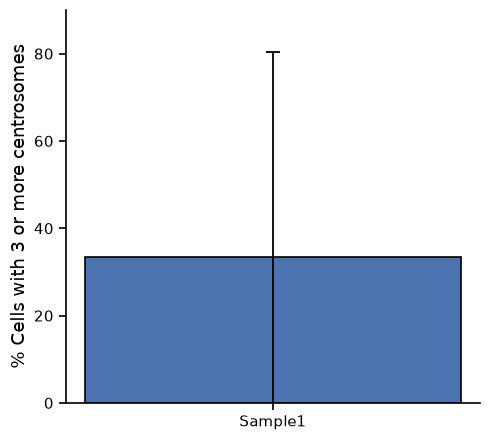

In [13]:
barplot_normal(
            df=results,
            output_dir=OUTPUT_DIR
               )

# TEST dataframe

In [ ]:
#import pandas as pd

data = {
    "Image": [
        "2_hct116_wt_pcdna_vacio_+_aph1a_g4__pcnt-gamma_tub-07",
        "2_hct116_wt_pcdna_vacio_+_aph1a_g4__pcnt-gamma_tub-07",
        "2_hct116_wt_pcdna_vacio_+_aph1a_g4__pcnt-gamma_tub-07",
        "2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04",
        "2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04",
        "2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04",
        "2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-05",
        "2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-05",
        "2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-05",
        "2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-05",
        "2_hct116_wt_aph1a_g4__pcnt-gamma_tub-01",
        "2_hct116_wt_aph1a_g4__pcnt-gamma_tub-01",
        "2_hct116_wt_aph1a_g4__pcnt-gamma_tub-01",
        "2_hct116_wt_aph1a_g4__pcnt-gamma_tub-02",
        "2_hct116_wt_aph1a_g4__pcnt-gamma_tub-02",
    ],

    "Cell": [
        1, 2, 3,
        1, 2, 3,
        1, 2, 3, 4,
        1, 2, 3,
        1, 2
    ],

    "Objects_number": [
        3, 2, 4,
        1, 2, 2,
        2, 3, 1, 2,
        4, 3, 5,
        2, 4
    ]
}

#df = pd.DataFrame(data)

# Add sample column manually
#df['Sample'] = df['Image'].apply(lambda x: 'sample1' if 'pcdna_vacio' in x else 'sample2')